In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import ast
import os

Matplotlib is building the font cache; this may take a moment.


In [5]:
#Set plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize']=(12,6)

#Create figures folder if needed
os.makedirs('outputs/figures', exist_ok=True)

print('Setup is complete!')

Setup is complete!


In [8]:
#Load the data
df =pd.read_csv('data/raw/studychat.csv')

print(f'Loaded {len(df)} rows')
print(f'Columns: {list(df.columns)}')
print(f' Shape: {df.shape}')

Loaded 16851 rows
Columns: ['prompt', 'response', 'topic', 'messages', 'timestamp', 'chatId', 'userId', 'interactionCount', 'chatTitle', 'chatStartTime', 'chatTotalInteractionCount', 'llm_label', 'semester']
 Shape: (16851, 13)


In [9]:
df.head()

,prompt,response,topic,messages,timestamp,chatId,userId,interactionCount,chatTitle,chatStartTime,chatTotalInteractionCount,llm_label,semester
0,"cross validation tests it on multiple sets, so...","Yes, cross-validation randomly splits your dat...",a4,"[{'content': 'You are a helpful assistant.', '...",1729128916365,58ee2342-6f95-460f-9323-3f4d422d5bc8,011bd560-70e1-7036-62a9-3d29afd5179d,6,The R-squared score,2024-10-16T18:09:18.602392,17,"{'label': 'contextual_questions>Other', 'justi...",f24
1,### Report on findings/significance for Polyno...,### Report on Findings/Significance for Polyno...,a4,"[{'content': 'You are a helpful assistant.', '...",1729140397817,58ee2342-6f95-460f-9323-3f4d422d5bc8,011bd560-70e1-7036-62a9-3d29afd5179d,12,The R-squared score,2024-10-16T18:09:18.602392,17,"{'label': 'writing_request>Write English', 'ju...",f24
2,what is KCL or KCI,KCl and KCI refer to the same chemical compoun...,a4,"[{'content': 'You are a helpful assistant.', '...",1729140819803,58ee2342-6f95-460f-9323-3f4d422d5bc8,011bd560-70e1-7036-62a9-3d29afd5179d,13,The R-squared score,2024-10-16T18:09:18.602392,17,{'label': 'conceptual_questions>Other Concept'...,f24
3,rmse_poly = root_mean_squared_error(y_test_pol...,Certainly! Let’s break down the code snippet y...,a4,"[{'content': 'You are a helpful assistant.', '...",1729136502322,58ee2342-6f95-460f-9323-3f4d422d5bc8,011bd560-70e1-7036-62a9-3d29afd5179d,7,The R-squared score,2024-10-16T18:09:18.602392,17,{'label': 'contextual_questions>Code Explanati...,f24
4,The R-squared score represents the proportion ...,"Certainly! The R-squared score, often denoted ...",a4,"[{'content': 'You are a helpful assistant.', '...",1729116578513,58ee2342-6f95-460f-9323-3f4d422d5bc8,011bd560-70e1-7036-62a9-3d29afd5179d,0,The R-squared score,2024-10-16T18:09:18.602392,17,{'label': 'contextual_questions>Assignment Cla...,f24


In [10]:
#Data types
print('Data types:')
print(df.dtypes)

Data types:
prompt                         str
response                       str
topic                          str
messages                       str
timestamp                    int64
chatId                         str
userId                         str
interactionCount             int64
chatTitle                      str
chatStartTime                  str
chatTotalInteractionCount    int64
llm_label                      str
semester                       str
dtype: object


In [11]:
#Basic stats
print('Basic stats:')
df.describe()

Basic stats:


,timestamp,interactionCount,chatTotalInteractionCount
count,1.685100e+04,16851.000000,16851.000000
mean,1.737422e+12,9.479141,19.271141
std,6.611212e+09,11.372442,17.195531
min,1.725393e+12,0.000000,0.000000
25%,1.730501e+12,2.000000,6.000000
50%,1.740258e+12,6.000000,14.000000
75%,1.742969e+12,13.000000,28.000000
max,1.746608e+12,103.000000,103.000000


In [13]:
# Missing values
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_percent
})

print('Missing values:')
print(missing_df[missing_df['Missing Count'] > 0])

Missing values:
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []


In [15]:
#Check llm_label format
print('Sample llm_label:')
print(df['llm_label'].iloc[0])
print('\n' +'='*50+'\n')

#Try to parse llm_label
def extract_label(label_str):
    try:
        if isinstance (Label_str, str):
            #Parse JSON
            label_dict = json.loads(label_str)
            return label_dict.get('Label', None)
        return None
    except:
        try:
            #Try ast.literal_eval
            label_dict = ast.literal_eval(label_str)
            return label_dict.get('label', None)
        except:
            return None

#Extract Labels
df['parsed_label'] = df ['llm_label'].apply(extract_label)

print('Parsed llm_label examples:')
print(df[['llm_label', 'parsed_label']].head())

Sample llm_label:
{'label': 'contextual_questions>Other', 'justification': 'The user is asking a specific question about how cross validation works, particularly whether it involves randomly selecting data from their dataset. This is a contextual question about the process described in the assignment.'}


Parsed llm_label examples:
                                           llm_label  \
0  {'label': 'contextual_questions>Other', 'justi...   
1  {'label': 'writing_request>Write English', 'ju...   
2  {'label': 'conceptual_questions>Other Concept'...   
3  {'label': 'contextual_questions>Code Explanati...   
4  {'label': 'contextual_questions>Assignment Cla...   

                                    parsed_label  
0                     contextual_questions>Other  
1                  writing_request>Write English  
2             conceptual_questions>Other Concept  
3          contextual_questions>Code Explanation  
4  contextual_questions>Assignment Clarification  


 Label categories distribution:
parsed_label
writing_request>Write Code                       2534
conceptual_questions>Python Library              1788
writing_request>Write English                    1340
conceptual_questions>Programming Language        1271
conceptual_questions>Computer Science            1178
contextual_questions>Assignment Clarification    1076
provide_context>Error Message                     979
contextual_questions>Code Explanation             950
provide_context>Other                             919
provide_context>Code                              696
contextual_questions>Interpret Output             513
conceptual_questions>Programming Tools            484
provide_context>Assignment Information            434
verification>Verify Code                          420
contextual_questions>Other                        399
writing_request>Code/Data Conversion              347
conceptual_questions>Other Concept                323
editing_request>Edit Code            

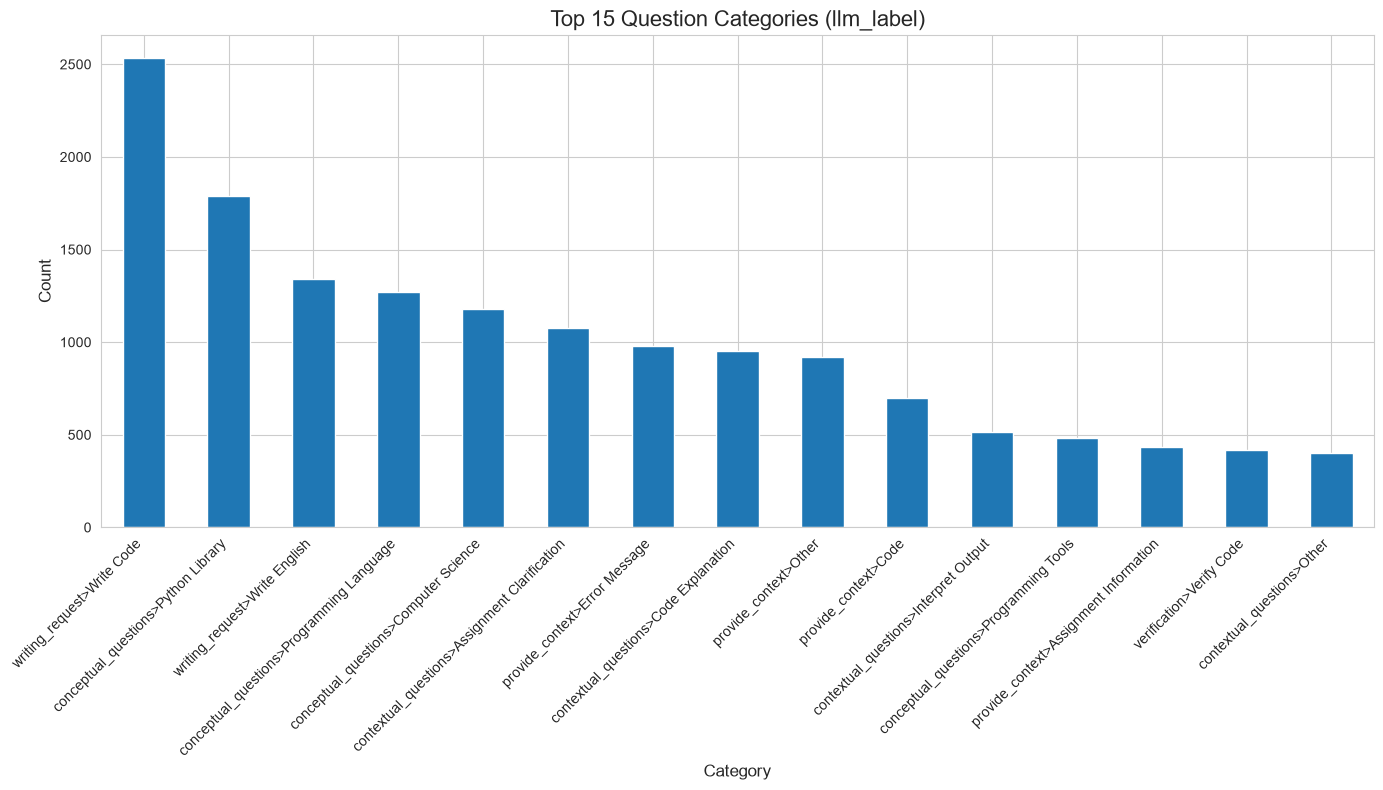

In [16]:
# Count label categories
label_counts = df['parsed_label'].value_counts()

print(' Label categories distribution:')
print(label_counts)

# Plot
plt.figure(figsize=(14, 8))
label_counts.head(15).plot(kind='bar')
plt.title('Top 15 Question Categories (llm_label)', fontsize=16)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('outputs/figures/studychat_label_distribution.png')
plt.show()

In [4]:
import json
import ast

def extract_label(label_str):
    try:
        if isinstance(label_str, str):
            label_dict = json.loads(label_str)
            return label_dict.get('label', None)
        return None
    except:
        try:
            label_dict = ast.literal_eval(label_str)
            return label_dict.get('label', None)
        except:
            return None

df['label'] = df['llm_label'].apply(extract_label)
print(f" Extracted {df['label'].nunique()} unique labels")
print(f"\nTop 10 labels:")
print(df['label'].value_counts().head(10))

✅ Extracted 32 unique labels

Top 10 labels:
label
writing_request>Write Code                       2534
conceptual_questions>Python Library              1788
writing_request>Write English                    1340
conceptual_questions>Programming Language        1271
conceptual_questions>Computer Science            1178
contextual_questions>Assignment Clarification    1076
provide_context>Error Message                     979
contextual_questions>Code Explanation             950
provide_context>Other                             919
provide_context>Code                              696
Name: count, dtype: int64


In [5]:
def map_to_meta_category(label):
    if pd.isna(label):
        return 'Other'
    label = str(label).lower()
    if 'writing_requests' in label:
        return 'Writing'
    if 'conceptual_questions' in label:
        return 'Conceptual'
    if 'contextual_questions' in label:
        return 'Contextual'
    if 'provide_context' in label:
        return 'Providing Context'
    if 'verification' in label:
        return 'Verification'
    return 'Other'

df['meta_category'] = df['label'].apply(map_to_meta_category)

meta_counts = df['meta_category'].value_counts()
print(" Meta-Category Distribution:")
print(pd.DataFrame({
    'Count': meta_counts,
    'Percentage': (meta_counts / len(df) * 100).round(2)
}))

📊 Meta-Category Distribution:
                   Count  Percentage
meta_category                       
Conceptual          5199       30.85
Other               5039       29.90
Providing Context   3028       17.97
Contextual          2938       17.44
Verification         647        3.84


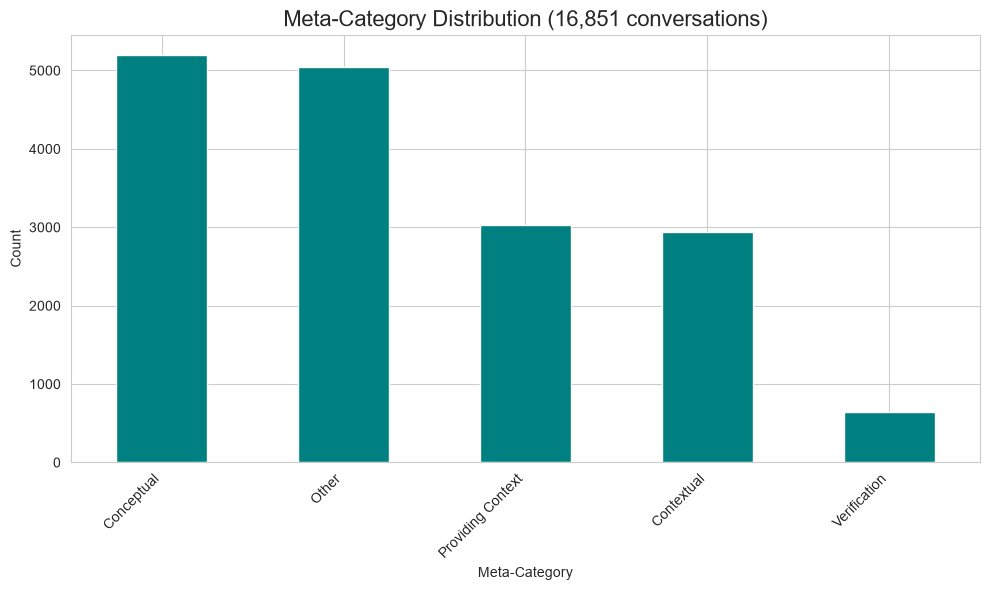

In [6]:
plt.figure(figsize=(10, 6))
meta_counts.plot(kind='bar', color='teal')
plt.title('Meta-Category Distribution (16,851 conversations)', fontsize=16)
plt.xlabel('Meta-Category')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('outputs/figures/meta_category_distribution.png')
plt.show()

In [8]:
print(" Available columns:")
for col in df.columns:
    print(f"  - {col}")

 Available columns:
  - prompt
  - response
  - topic
  - messages
  - timestamp
  - chatId
  - userId
  - interactionCount
  - chatTitle
  - chatStartTime
  - chatTotalInteractionCount
  - llm_label
  - semester
  - label
  - prompt_length
  - response_length
  - parsed_messages
  - num_turns
  - meta_category


In [9]:
# Create missing features
df['prompt_length'] = df['prompt'].str.len()
df['prompt_word_count'] = df['prompt'].str.split().str.len()
df['response_length'] = df['response'].str.len()

print(" Features created:")
print(df[['prompt_length', 'prompt_word_count', 'response_length']].describe())

 Features created:
       prompt_length  prompt_word_count  response_length
count   16851.000000       16851.000000     16851.000000
mean      775.283781         102.255593      2788.222835
std      4680.644801         689.767752      1277.751803
min         1.000000           0.000000        15.000000
25%        45.000000           8.000000      1977.500000
50%       115.000000          19.000000      2768.000000
75%       549.500000          72.000000      3584.000000
max    503572.000000       72540.000000      9721.000000


In [10]:
import os

# Step 1: Ensure all features exist
print("="*60)
print("🔧 ENSURING ALL FEATURES EXIST")
print("="*60)

# Create missing features (if they don't exist)
if 'prompt_length' not in df.columns:
    df['prompt_length'] = df['prompt'].str.len()
    print("   Created: prompt_length")

if 'prompt_word_count' not in df.columns:
    df['prompt_word_count'] = df['prompt'].str.split().str.len()
    print("   Created: prompt_word_count")

if 'response_length' not in df.columns:
    df['response_length'] = df['response'].str.len()
    print("   Created: response_length")

if 'num_turns' not in df.columns:
    import json, ast
    def parse_messages(msg_str):
        try:
            if isinstance(msg_str, str):
                return json.loads(msg_str)
            return msg_str
        except:
            try:
                return ast.literal_eval(msg_str)
            except:
                return None
    df['parsed_messages'] = df['messages'].apply(parse_messages)
    df['num_turns'] = df['parsed_messages'].apply(lambda x: len(x) if isinstance(x, list) else 0)
    print("   Created: num_turns")

if 'meta_category' not in df.columns:
    def map_to_meta_category(label):
        if pd.isna(label):
            return 'Other'
        label = str(label).lower()
        if 'writing_requests' in label:
            return 'Writing'
        if 'conceptual_questions' in label:
            return 'Conceptual'
        if 'contextual_questions' in label:
            return 'Contextual'
        if 'provide_context' in label:
            return 'Providing Context'
        if 'verification' in label:
            return 'Verification'
        return 'Other'
    
    # Ensure label exists first
    if 'label' not in df.columns:
        import json, ast
        def extract_label(label_str):
            try:
                if isinstance(label_str, str):
                    label_dict = json.loads(label_str)
                    return label_dict.get('label', None)
                return None
            except:
                try:
                    label_dict = ast.literal_eval(label_str)
                    return label_dict.get('label', None)
                except:
                    return None
        df['label'] = df['llm_label'].apply(extract_label)
    
    df['meta_category'] = df['label'].apply(map_to_meta_category)
    print("   Created: meta_category")

# Step 2: Define columns to keep
columns_to_keep = [
    'prompt',
    'response',
    'topic',
    'meta_category',
    'prompt_length',
    'prompt_word_count',
    'response_length',
    'num_turns',
    'chatId',
    'userId',
    'semester'
]

# Step 3: Keep only columns that exist
existing_columns = [col for col in columns_to_keep if col in df.columns]
missing_columns = [col for col in columns_to_keep if col not in df.columns]

print(f"\n Columns kept: {len(existing_columns)}")
print(f" Columns missing: {missing_columns}")

# Step 4: Create cleaned DataFrame
df_cleaned = df[existing_columns].copy()

# Step 5: Rename for clarity
df_cleaned = df_cleaned.rename(columns={
    'meta_category': 'label',
    'chatId': 'chat_id',
    'userId': 'user_id'
})

# Step 6: Save
os.makedirs('data/processed', exist_ok=True)
df_cleaned.to_csv('data/processed/studychat_cleaned.csv', index=False)

print("\n" + "="*60)
print(" DATA PREPROCESSING COMPLETE")
print("="*60)
print(f"\n BEFORE:")
print(f"   Rows: {len(df)}")
print(f"   Columns: {len(df.columns)}")
print(f"\n AFTER:")
print(f"   Rows: {len(df_cleaned)}")
print(f"   Columns: {len(df_cleaned.columns)}")
print(f"\n Final columns: {list(df_cleaned.columns)}")
print(f"\n Saved to: data/processed/studychat_cleaned.csv")

🔧 ENSURING ALL FEATURES EXIST

 Columns kept: 11
 Columns missing: []

 DATA PREPROCESSING COMPLETE

 BEFORE:
   Rows: 16851
   Columns: 20

 AFTER:
   Rows: 16851
   Columns: 11

 Final columns: ['prompt', 'response', 'topic', 'label', 'prompt_length', 'prompt_word_count', 'response_length', 'num_turns', 'chat_id', 'user_id', 'semester']

 Saved to: data/processed/studychat_cleaned.csv


In [11]:
# Check the saved file
import pandas as pd
df_check = pd.read_csv('data/processed/studychat_cleaned.csv')
print(f" Saved file has {len(df_check)} rows")
print(f" Columns: {list(df_check.columns)}")
print(f"\n First 3 rows:")
print(df_check.head(3))

 Saved file has 16851 rows
 Columns: ['prompt', 'response', 'topic', 'label', 'prompt_length', 'prompt_word_count', 'response_length', 'num_turns', 'chat_id', 'user_id', 'semester']

 First 3 rows:
                                              prompt  \
0  cross validation tests it on multiple sets, so...   
1  ### Report on findings/significance for Polyno...   
2                                 what is KCL or KCI   

                                            response topic       label  \
0  Yes, cross-validation randomly splits your dat...    a4  Contextual   
1  ### Report on Findings/Significance for Polyno...    a4       Other   
2  KCl and KCI refer to the same chemical compoun...    a4  Conceptual   

   prompt_length  prompt_word_count  response_length  num_turns  \
0             98                 17              349         14   
1           1807                275             2159         26   
2             18                  5             1142         28   

           